# Домашнє завдання: Класифікація спаму (Вступ до NLP)
**Мета:** Побудувати модель класифікації електронних листів на спам та не-спам (ham) за допомогою методів Bag-of-Words (BoW), TF-IDF та попередньо навчених векторних представлень слів (Embeddings).

## 1. Імпорт необхідних бібліотек

In [12]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
import gensim.downloader as api

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Підготовка даних: автоматичний пошук та завантаження датасету

In [11]:
# Пошук файлу датасету, щоб ноутбук працював з різних місць
CANDIDATE_PATHS = ['spam.csv', './data/spam.csv', '/content/spam.csv']

DATASET_PATH = None
for p in CANDIDATE_PATHS:
    if os.path.exists(p):
        DATASET_PATH = p
        break

if DATASET_PATH is None and os.path.isdir('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'spam.csv' in files:
            DATASET_PATH = os.path.join(root, 'spam.csv')
            break

if DATASET_PATH is None:
    raise FileNotFoundError(
        "Датасет 'spam.csv' не знайдено. На Kaggle додайте датасет через 'Add Input' "
        "(Email Spam Detection Dataset), або, якщо працюєте локально/у Colab, покладіть "
        "файл spam.csv у ту саму папку, що й цей ноутбук."
    )

print(f'Знайдено датасет: {DATASET_PATH}')

# Кодування latin-1, бо датасет містить специфічні символи
df = pd.read_csv(DATASET_PATH, encoding='latin-1')

# Оригінальний файл містить зайві порожні колонки (Unnamed: 2, 3, 4)
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонки")
print('-' * 50)
print('Розподіл цільової змінної (%):')
print(df['label'].value_counts(normalize=True) * 100)
print('-' * 50)
display(df.head())

Знайдено датасет: /kaggle/input/datasets/shantanudhakadd/email-spam-detection-dataset-classification/spam.csv
Розмір датасету: 5572 рядків, 2 колонки
--------------------------------------------------
Розподіл цільової змінної (%):
label
0    86.593683
1    13.406317
Name: proportion, dtype: float64
--------------------------------------------------


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


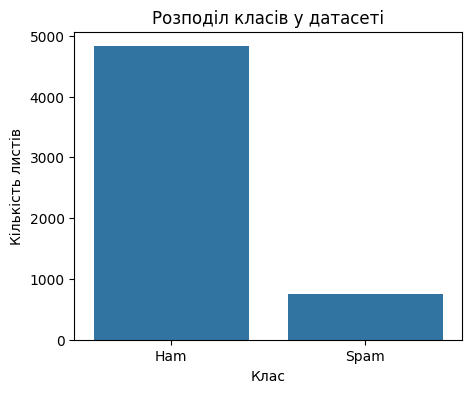

In [8]:
# Візуалізація розподілу класів — наочно показати дисбаланс,
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=df['label'].map({0: 'Ham', 1: 'Spam'}), ax=ax, hue=None)
ax.set_title('Розподіл класів у датасеті')
ax.set_xlabel('Клас')
ax.set_ylabel('Кількість листів')
plt.show()

## 3. Попередня обробка тексту та розбиття даних

1. Привести всі слова до нижнього регістру.
2. Видалити пунктуацію, спеціальні символи та цифри.
3. Видалити стоп-слова (частовживані слова, які не несуть семантичного навантаження, наприклад, "the", "a", "is").

Після очищення датасет розбиваємо на навчальну та валідаційну вибірки у пропорції 80/20. Використовуємо `stratify`, щоб зберегти оригінальну пропорцію спаму та звичайних листів у обох наборах.

In [4]:
# Ініціалізація набору стоп-слів англійської мови
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Приведення до нижнього регістру
    text = text.lower()
    # Видалення всіх символів, крім літер англійського алфавіту та пробілів
    text = re.sub(r'[^a-z\s]', '', text)
    # Токенізація та фільтрація стоп-слів
    words = text.split()
    words = [word for word in words if word not in stop_words]
    # Об'єднання слів назад у рядок
    return ' '.join(words)

# Створення нової колонки з очищеним текстом
df['clean_text'] = df['text'].apply(clean_text)

# Розбиття даних на навчальну (80%) та валідаційну (20%) вибірки
X_train, X_val, y_train, y_val = train_test_split(
    df['clean_text'], 
    df['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label']
)

# Вивід результатів для перевірки
print(f"Розмір навчальної вибірки: {X_train.shape[0]} рядків")
print(f"Розмір валідаційної вибірки: {X_val.shape[0]} рядків")
print("-" * 50)
display(df[['text', 'clean_text']].head())

Розмір навчальної вибірки: 4457 рядків
Розмір валідаційної вибірки: 1115 рядків
--------------------------------------------------


,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## 4. Bag of Words та TF-IDF

Використовуємо:
1. CountVectorizer (Bag of Words)
2. TfidfVectorizer (TF-IDF)

Обмежимо словник до 3000 найважливіших ознак (`max_features=3000`) та використаємо уніграми і біграми (`ngram_range=(1, 2)`).

* `max_features=3000` (Для захисту від перенавчання та оптимізація пам'яті)
* `ngram_range=(1, 2)` (Для розуміння стійких виразів)

In [5]:
# Ініціалізація векторизаторів
bow_vectorizer = CountVectorizer(max_features=3000, ngram_range=(1, 2))
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

# Навчання (fit) та трансформація для Bag of Words на навчальній вибірці
X_train_bow = bow_vectorizer.fit_transform(X_train)
# Тільки трансформація для валідаційної вибірки
X_val_bow = bow_vectorizer.transform(X_val)

# Навчання та трансформація для TF-IDF
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# Перевірка розмірностей
print("Розмірність матриці BoW (train):", X_train_bow.shape)
print("Розмірність матриці TF-IDF (train):", X_train_tfidf.shape)
print("Розмірність матриці BoW (val):", X_val_bow.shape)

Розмірність матриці BoW (train): (4457, 3000)
Розмірність матриці TF-IDF (train): (4457, 3000)
Розмірність матриці BoW (val): (1115, 3000)


## 5. Embeddings

Використовуємо GloVe (100 вимірів) через бібліотеку `gensim`. Щоб отримати єдиний вектор для всього електронного листа, ми обчислимо середнє арифметичне векторів усіх слів, що входять до нього (Mean Pooling).

In [6]:
# Завантаження моделі GloVe
print("Завантаження моделі GloVe...")
embed_model = api.load("glove-wiki-gigaword-100")
print("Модель успішно завантажено!")

def get_sentence_embedding(sentence, model):
    words = sentence.split()
    # Залишаємо лише ті слова, вектор яких відомий моделі
    valid_words = [word for word in words if word in model]
    
    if valid_words:
        # Mean Pooling
        return np.mean(model[valid_words], axis=0)
    else:
        # Якщо слова повністю відсутні в словнику, повертаємо нульовий вектор
        return np.zeros(model.vector_size)

# Перетворення тексту на вектори ембедінгів
X_train_embed = np.array([get_sentence_embedding(text, embed_model) for text in X_train])
X_val_embed = np.array([get_sentence_embedding(text, embed_model) for text in X_val])

# Перевірка розмірностей
print("Розмірність матриці ембедінгів (train):", X_train_embed.shape)
print("Розмірність матриці ембедінгів (val):", X_val_embed.shape)

Завантаження моделі GloVe...
[==================================================] 100.0% 128.1/128.1MB downloaded
Модель успішно завантажено!
Розмірність матриці ембедінгів (train): (4457, 100)
Розмірність матриці ембедінгів (val): (1115, 100)


## 6. Побудова, навчання та оцінка моделей

Датасет сильно незбалансований (~87% ham / ~13% spam), тому саму лише Accuracy недостатньо (модель, що завжди передбачає "ham", матиме Accuracy ≈ 0.87). Тому додатково рахуємо AUC (стійкий до дисбалансу класів, показує якість ранжування) та F1-score для класу Spam (баланс між Precision і Recall саме для мінорного класу).

Для BoW і TF-IDF використовуємо `LogisticRegression` (базовий підхід для розріджених текстових векторів). Для ембедінгів навчаємо іншу модель (`RandomForestClassifier`), оскільки щільні вектори embeddings краще підходять для нелінійних ансамблевих методів, ніж для розріджених BoW/TF-IDF векторів.

--- Результати для: Bag of Words (BoW) + LogisticRegression ---
Accuracy: 0.9803
AUC:      0.9853
F1 (spam):0.9203

Детальний звіт (Precision, Recall, F1-score):
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       966
    Spam (1)       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



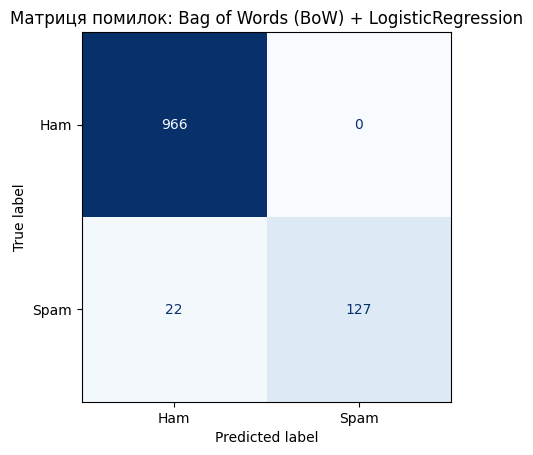

--- Результати для: TF-IDF + LogisticRegression ---
Accuracy: 0.9686
AUC:      0.9851
F1 (spam):0.8699

Детальний звіт (Precision, Recall, F1-score):
              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.98       966
    Spam (1)       0.97      0.79      0.87       149

    accuracy                           0.97      1115
   macro avg       0.97      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



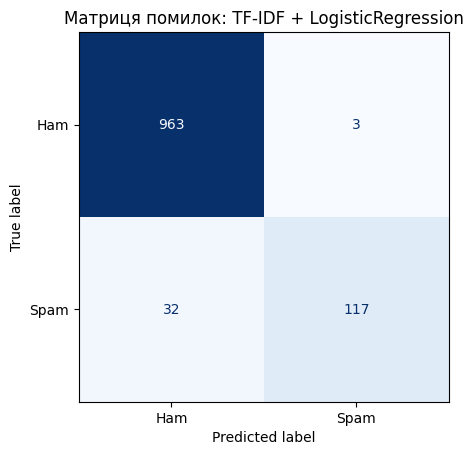

--- Результати для: GloVe Embeddings + RandomForestClassifier ---
Accuracy: 0.9587
AUC:      0.9470
F1 (spam):0.8217

Детальний звіт (Precision, Recall, F1-score):
              precision    recall  f1-score   support

     Ham (0)       0.96      1.00      0.98       966
    Spam (1)       0.97      0.71      0.82       149

    accuracy                           0.96      1115
   macro avg       0.96      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



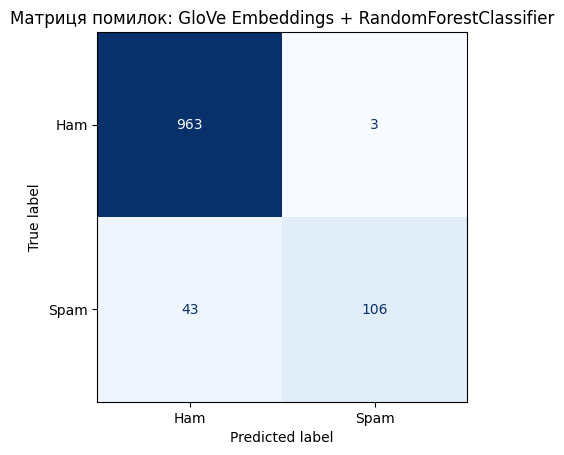

In [13]:
def train_and_evaluate(model, X_train_data, X_val_data, model_name):
    model.fit(X_train_data, y_train)

    y_pred = model.predict(X_val_data)
    y_pred_proba = model.predict_proba(X_val_data)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    f1_spam = f1_score(y_val, y_pred, pos_label=1)

    print(f'--- Результати для: {model_name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(f'AUC:      {auc:.4f}')
    print(f'F1 (spam):{f1_spam:.4f}')
    print('\nДетальний звіт (Precision, Recall, F1-score):')
    print(classification_report(y_val, y_pred, target_names=['Ham (0)', 'Spam (1)']))

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    disp.plot(cmap='Blues', colorbar=False)
    plt.title(f'Матриця помилок: {model_name}')
    plt.show()
    print('=' * 50)

    return {'model': model_name, 'accuracy': acc, 'auc': auc, 'f1_spam': f1_spam}

results = []
results.append(train_and_evaluate(LogisticRegression(max_iter=1000, random_state=42),
                                   X_train_bow, X_val_bow, 'Bag of Words (BoW) + LogisticRegression'))
results.append(train_and_evaluate(LogisticRegression(max_iter=1000, random_state=42),
                                   X_train_tfidf, X_val_tfidf, 'TF-IDF + LogisticRegression'))
results.append(train_and_evaluate(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
                                   X_train_embed, X_val_embed, 'GloVe Embeddings + RandomForestClassifier'))

In [14]:
# Зведена таблиця для наочного порівняння всіх підходів
results_df = pd.DataFrame(results).set_index('model')
display(results_df.style.format('{:.4f}').highlight_max(color='lightgreen', axis=0))

,accuracy,auc,f1_spam
model,,,
Bag of Words (BoW) + LogisticRegression,0.9803,0.9853,0.9203
TF-IDF + LogisticRegression,0.9686,0.9851,0.8699
GloVe Embeddings + RandomForestClassifier,0.9587,0.9470,0.8217


In [16]:
best_by_auc = results_df['auc'].idxmax()
worst_by_auc = results_df['auc'].idxmin()

print('Автоматичний підсумок на основі отриманих метрик:\n')
for row in results_df.itertuples():
    print(f'- {row.Index}: Accuracy={row.accuracy:.4f}, AUC={row.auc:.4f}, F1(spam)={row.f1_spam:.4f}')

print(f"\nНайкращий результат за AUC показав підхід: '{best_by_auc}'.")
print(f"Найнижчий результат за AUC показав підхід: '{worst_by_auc}'.")

Автоматичний підсумок на основі отриманих метрик:

- Bag of Words (BoW) + LogisticRegression: Accuracy=0.9803, AUC=0.9853, F1(spam)=0.9203
- TF-IDF + LogisticRegression: Accuracy=0.9686, AUC=0.9851, F1(spam)=0.8699
- GloVe Embeddings + RandomForestClassifier: Accuracy=0.9587, AUC=0.9470, F1(spam)=0.8217

Найкращий результат за AUC показав підхід: 'Bag of Words (BoW) + LogisticRegression'.
Найнижчий результат за AUC показав підхід: 'GloVe Embeddings + RandomForestClassifier'.


## 7. Аналіз результатів та висновки

У задачах класифікації коротких текстів (як-от SMS чи email-спам) наявність специфічних слів-тригерів (`'free'`, `'win'`, `'call now'`) відіграє вирішальну роль. Розріджені матриці (`BoW/TF-IDF`) вловлюють ці маркери, присвоюючи кожному слову окрему вагу. `BoW` показав себе найкраще, оскільки зберіг ідеальну точність (`Precision=1.00`) для мінорного класу.

Натомість використання `Mean Pooling` для попередньо навчених ембедінгів (`GloVe`) усереднює вектори всіх слів. Через це сильний сигнал від окремих спам-маркерів розмивається загальним нейтральним фоном повідомлення. Для складніших NLU-пайплайнів (наприклад, розпізнавання інтентів чи ентіті) глибока семантика щільних векторів є перевагою, проте для спам-фільтрування проста частотна статистика слів виявилася значно ефективнішою, навіть порівняно з алгоритмом `RandomForest`.

## 8. Вдосконалення моделі: підбір гіперпараметрів

Найкраще значення C: 10
Найкращий крос-валідаційний AUC: 0.9883
--- Результати для: TF-IDF + LogisticRegression (tuned C) ---
Accuracy: 0.9821
AUC:      0.9866
F1 (spam):0.9286

Детальний звіт (Precision, Recall, F1-score):
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       966
    Spam (1)       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



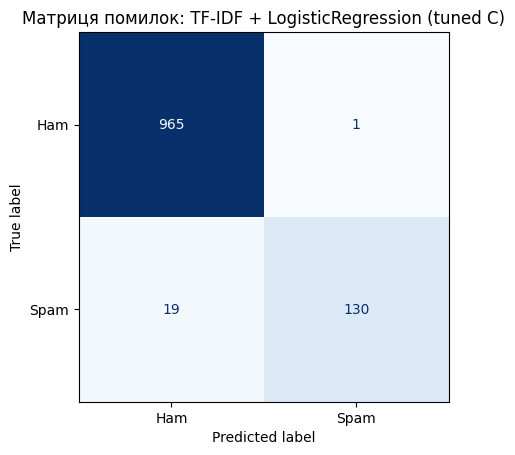


AUC до підбору гіперпараметрів: 0.9851
AUC після підбору гіперпараметрів: 0.9866


In [17]:
# Підбір гіперпараметра C для LogisticRegression
# на TF-IDF представленні за допомогою крос-валідації (5-fold) за метрикою AUC.
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
grid.fit(X_train_tfidf, y_train)

print('Найкраще значення C:', grid.best_params_['C'])
print(f'Найкращий крос-валідаційний AUC: {grid.best_score_:.4f}')

best_model = grid.best_estimator_
tuned_result = train_and_evaluate(best_model, X_train_tfidf, X_val_tfidf,
                                   'TF-IDF + LogisticRegression (tuned C)')

baseline_auc = results_df.loc['TF-IDF + LogisticRegression', 'auc']
print(f"\nAUC до підбору гіперпараметрів: {baseline_auc:.4f}")
print(f"AUC після підбору гіперпараметрів: {tuned_result['auc']:.4f}")

## Висновки щодо GridSearchCV

Модель TF-IDF + LogisticRegression поступалася Bag of Words, і мала потенціал для оптимізації. Застосування крос-валідації для пошуку найкращого параметра регуляризації C (який склав 10) дозволило покращити її результати:
- Метрика AUC зросла з 0.9851 до 0.9866.
- F1-score для класу спаму піднявся з 0.8699 до 0.9286.

Це демонструє потенціал підбору гіперпараметрів: правильне налаштування штрафів за перенавчання у поєднанні з TF-IDF-зважуванням дозволяє моделі набагато точніше виділяти важливі спам-маркери.